## Statistics project 2025 Giuseppe Luciano

In [249]:
# M2 Statistics project 2025
# date : 10 november 2025
# Author : Giuseppe Luciano
# course IMAPP

In [250]:
#importing usefull library
import numpy as np
import matplotlib.pyplot as plt
from mpmath import mp
from scipy import optimize
from scipy.stats import chi2
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display, Math
import sys
sys.set_int_max_str_digits(int(1e6))
%matplotlib inline


1. Compute the frequency $f_d$ of each of the ten digits d in [0, 9] in a sequence of N = 5 × $10^4$ digits of $\pi$ (standard base-10)

In [251]:
N=int(9e6) # N increased for better analysis as suggested in the comment.
mp.dps = N # set number of digits
pi=str(mp.pi).replace('.','') #remove the dot
frequencies = {str(d): pi.count(str(d))/len(pi) for d in range(10)}
#initialize a dictionary in which every digit are associate to their frequency

2. Draw the histogram of frequencies, $f_d$ versus d, with error-bars $\pm \sigma$

In [252]:
def plot_freq(freq_array, error, expected, title, digits = np.arange(0,10), overlay = None):
    '''
     Plot the frequency distribution of each digit.
    '''
    plt.figure(figsize=(10, 6))
    # Plot a bar chart with error bars
    plot_style = {'color':'royalblue',
        'alpha':0.8,
        'edgecolor':'black',
        'capsize':5
    }

    plt.bar(digits, freq_array, yerr=error, **plot_style)

    # Add a horizontal dashed line showing the expected value (0.1)
    if expected is not None:
        plt.axhline(
            expected,
            color='red',
            linestyle='--',
            linewidth=2,
            label='Expected'
     )

    if overlay is not None:
        plt.plot(digits, overlay, color='red', lw=2, label='Fit')

    # Label each bar with its numeric frequency value
    for d, f in zip(digits, freq_array):
        plt.text(d, f + 0.0003, f"{f:.4f}", ha='center', va='bottom', fontsize=9, color='black')

    # Add title and axis labels
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Digit (d)", fontsize=12)
    plt.ylabel(f"Relative Frequency $f_d$", fontsize=12)
    plt.ylim(0, np.max(freq_array)*(1+0.25))  # set y-axis range
    plt.xticks(digits, [str(d) for d in digits]) # add label for each bin

    # Add gridlines and legend for clarity
    plt.grid(axis='y', linestyle=':', alpha=0.8)
    plt.legend()
    plt.show()


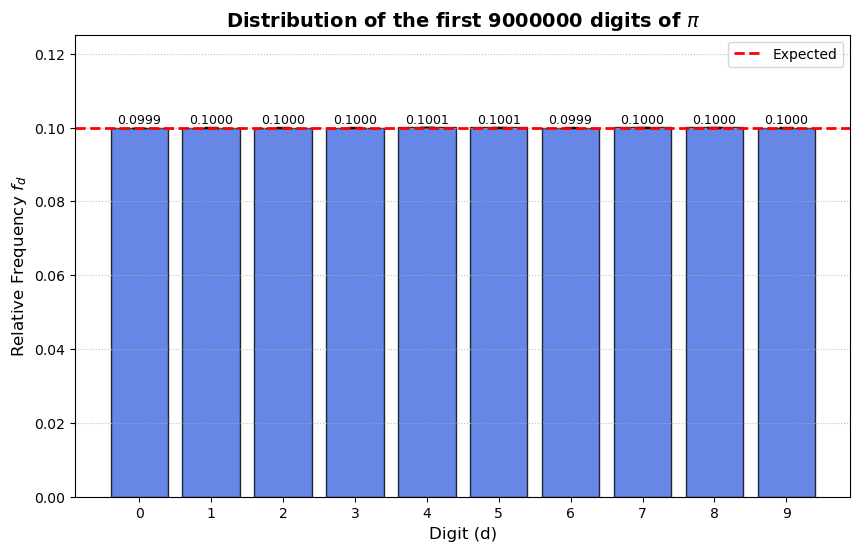

In [253]:
# Convert the dictionary into an ordered NumPy array
digits = np.arange(10)
freq_array = np.array([frequencies[str(d)] for d in digits])

# Compute the binomial standard deviation for each frequency
# sigma = sqrt(p*(1-p)/N).
error = np.sqrt(freq_array * (1 - freq_array) / N)
expected = 1/10
plot_freq(freq_array, error, expected, f'Distribution of the first {N} digits of $\pi$')

The histogram of the digit frequencies appears remarkably flat, indicating that each digit from 0 to 9 occurs with roughly equal probability. The measured frequencies are all very close to the expected value of 0.1, which is consistent with the hypothesis that the digits of π are uniformly distributed.

The small deviations from the expected value fall well within the statistical uncertainties, confirming that there is no significant bias toward any particular digit. This visual agreement between the observed frequencies and the expected value reinforces the conclusion that the digits of $\pi$ behave as a random sequence in terms of single-digit occurrences.

3. fit the two-parameter linear function:

In [254]:
#defining the fit function
def linear(d,a,b):
    """
    Linear model function: f(d) = a/10 + b*d
    """
    
    return a/10+b*d

def print_scientific(param_name, value, error):
    """
    Print a parameter with its uncertainty in scientific notation,
    automatically adjusting significant digit.
    
    - Error always has 2 significant digits.
    - Value is rounded so its last digit corresponds to the last digit of the error.
    Format: param_name = (value ± error) × 10^exponent
    """
    if value == 0:
        print(f"{param_name} = (0 ± {error:.2e})")
        return

    # Determine exponent for first non null digit
    if error == 0:
        error_exponent = 0
    else:
        error_exponent = int(np.floor(np.log10(abs(error))))
    
    if value == 0:
        value_exponent = 0
    else:
        value_exponent = int(np.floor(np.log10(abs(value))))


    #rescale value and error
    value = value / 10**value_exponent     
    error = error / 10**value_exponent

    
    # Round error to 2 significant digits
    error = round(error, 1 - int(np.floor(np.log10(error))))

    # Determine number of decimal places for value
    # So its last digit matches the second significant digit of error
    decimal_places = max(0, -int(np.floor(np.log10(error))) + 1)

    # Round value accordingly
    value = round(value, decimal_places)
    
    # Print result
    print(f"{param_name} = ({value} ± {error}) × 10^{value_exponent}")


In [255]:
# Fit the model to the data
par, cov = optimize.curve_fit(linear, digits, freq_array, sigma=error)

# Extract best-fit parameters
aBest, bBest = par

#Compute parameter uncertainties (1sigma errors from covariance matrix)
aErr, bErr = np.sqrt(np.diag(cov))


# Print results in scientific notation  
print_scientific("best estimation of a", aBest, aErr)
print_scientific("best estimation of b", bBest, bErr)

#printing the covariant matrix
print('='*80, '\n')
print(cov)

best estimation of a = (9.996 ± 0.004) × 10^-1
best estimation of b = (8.8 ± 7.5) × 10^-6

[[ 1.60917561e-07 -2.54076439e-09]
 [-2.54076439e-09  5.64694243e-11]]


The equiprobability hypothesis fd = 1/10 would correspond to the parameters point $\mu$ = $(\alpha_0, \beta_0)$ = (1.0, 0.0). As we can see ther's a good agreement with the result basing also on the uncertanties. 

The best-fit parameters obtained from fitting the linear model to the digit frequency data are very close to the expected values under the constant hypothesis, where 
$\alpha$=1and $\beta$=0. The parameter estimates, are compatible with these theoretical values within their 1 $\sigma$ uncertainties, as indicated by the covariance matrix.

This agreement shows that the linear fit does not significantly deviate from a constant model, confirming that the observed digit frequencies are consistent with a uniform distribution. In other words, the data supports the hypothesis that each digit occurs with roughly equal probability, and there is no detectable bias in the distribution of the digits of $\pi$.

Compute the $\chi^2_{min}$ using 
$\chi^2_{min} = \sum_{d=0}^9 (\frac{f_d-f^{lin}(d, \hat{\alpha},\hat{\beta})}{\sigma_{f_d}})^2$ 

In [256]:
# Calculate Chi-squared (ChiMin)
def calculate_chi(freq_array, error, model, digits, *par):
    ''' 
    this function calculate the reduced chisquare and the p value
    given a model 
    '''
    chi_min = np.sum(((freq_array - model(digits, *par)) / error) ** 2)

    # Calculate reduced chi-squared (ChiMin divided by degrees of freedom (8)
    NDOF = (len(freq_array)-len(par))
    reduced_chi = chi_min / NDOF

    # Calculate p-value
    p_value =chi2.sf(chi_min, NDOF)

    # Print results
    print(f"Reduced chi-squared = {reduced_chi:.4f}")
    print(f"p-value = {p_value:.4f}")

In [257]:
calculate_chi(freq_array, error, linear, np.arange(10), aBest, bBest)

Reduced chi-squared = 0.4660
p-value = 0.8808


If the statistical fluctuations around the theoretical model are Normally-distributed we expect the $\chi^2_{min}$ per degree-of-freedom to be close to unity. The reduced chi-squared value of 0.466 is well below 1, indicating that the observed data are very consistent with the fitted model and that the deviations from the model predictions are smaller than expected from the statistical uncertainties. This suggests that either the model describes the data well or that the estimated errors may be slightly overestimated.

The corresponding p-value of 0.88 further supports this interpretation: such a high value means that there is an 88% probability of obtaining a chi-squared value this large (or larger) purely by chance if the model is correct. Therefore, there is no reason to reject the model hypothesis.

Both the low reduced chi-squared and the high p-value indicate a very good agreement between the observed frequencies and the expected model, confirming the validity of the constant (uniform) hypothesis.

5. Using the covariance C returned by the least-squares fit, draw the covariance error ellipse corresponding to a 95% confidence level in the two-dimensional parameter space p = $(\alpha, \beta)$:

In [258]:
# Compute eigenvalues and eigenvectors of the covariance matrix 
def draw_ellipse(cov, aBest, bBest, a0=1, b0 = 0):
    '''
    This function draw the covariance error ellipse both for
    1 sigma confidence level, in red, and 95% confidence level, in orange
    '''
    eigvals, eigvecs = np.linalg.eigh(cov)  # cov is a 2x2 covariance matrix

    # Confidence levels
    alpha1 = chi2.ppf(0.6827, df=2)  # 1 sigma ~68.27%
    alpha95 = chi2.ppf(0.95, df=2)   # 95%

    # Create points of a unit circle
    theta = np.linspace(0, 2*np.pi, 800)
    circle = np.stack((np.cos(theta), np.sin(theta)))

    # 1sigma ellipse with linear algebra calculations
    axes1 = np.sqrt(alpha1 * eigvals)
    ellipse1 = eigvecs @ np.diag(axes1) @ circle
    center = np.array([[aBest], [bBest]])
    ellipse1 = ellipse1 + center
    
    # 95% ellipse 
    axes95 = np.sqrt(alpha95 * eigvals)
    ellipse95 = eigvecs @ np.diag(axes95) @ circle
    ellipse95 = ellipse95 + center
    
    #Plotting
    plt.figure(figsize=(10, 7))
    # Plot the center
    plt.plot(*center, 'ko', markersize=6, label='Ellipse center')
    #equiprobability hypothesis
    plt.plot(a0, b0, 'bo', markersize=6, label='Equiprobability hypothesis')

    # difference vector
    d = np.array([a0 - aBest, b0 - bBest])
    delta_chi2 = d.T @ np.linalg.solve(cov, d)

    p_value = chi2.sf(delta_chi2, df=2)
    display(Math(r"\Delta \chi^2(\alpha_0, \beta_0) = {:.4f}".format(delta_chi2)))


    display(Math(r"p-value(\Delta \chi^2(\alpha_0, \beta_0)) = {:.4f}".format(p_value)))
    
    # Cosmetic improvements
    plt.title('Confidence Ellipses', fontsize=14, fontweight='bold')
    plt.xlabel(r'$\alpha$', fontsize=12)
    plt.ylabel(r'$\beta$', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    # Fill the ellipses with transparent color
    plt.fill(ellipse95[0], ellipse95[1], color='orange', alpha=0.3, label='95% confidence')
    plt.fill(ellipse1[0], ellipse1[1], color='red', alpha=0.5, label=f'1$\sigma$ confidence')
    plt.legend()
    ymin, ymax = ellipse95[1].min(), ellipse95[1].max()
    dy = (ymax - ymin) * 0.2
    plt.ylim(ymin - dy, ymax + dy)
    plt.xticks(ticks=plt.xticks()[0][::2])  
    
    
    # Draw the borders of the ellipses
    plt.plot(ellipse95[0], ellipse95[1], 'orange', linewidth=2)
    plt.plot(ellipse1[0], ellipse1[1], 'red', linewidth=2)
    plt.show()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

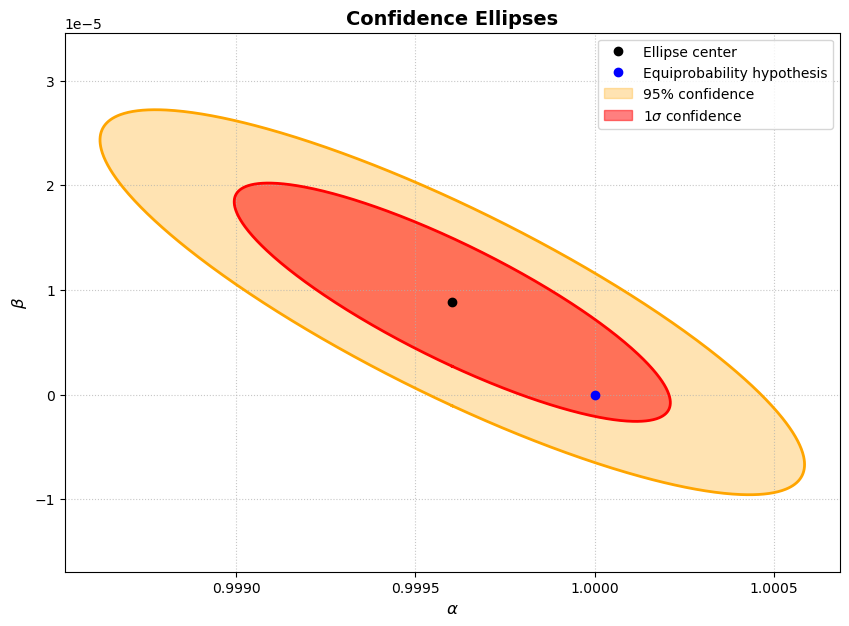

In [259]:
draw_ellipse(cov, aBest, bBest)

The fact that the point corresponding to the constant hypothesis lies within the 1$\sigma$ confidence ellipse indicates that it is consistent with the best-fit parameters within the 68% confidence level. The computed Δχ² value of 1.3 is smaller than the threshold for the 1$\sigma$ ellipse in two dimensions ($\Delta \chi^2$ ≈ 2.30), confirming that the hypothesis is not significantly different from the best-fit point.

The p-value of 0.5 further supports this interpretation: it represents the probability of observing a Δχ² larger than 1.3 purely due to statistical fluctuations. A p-value of 0.5 is relatively high, meaning there is no evidence to reject the constant hypothesis, and the hypothesis lies comfortably within the region of high likelihood defined by the covariance of the parameters.

In [260]:
#resume all the previous step in a single function
def lucas(n):
    """Returns the nth Lucas number"""
    if n == 0:
        return 2
    if n == 1:
        return 1
    a, b = 2, 1
    for step in range(2, int(n) + 1):
        a, b = b, a + b
    return b

def padovan(n):
    """Returns the nth padovan number"""
    if n <= 2:
        return 1
    p0, p1, p2 = 1, 1, 1
    for step in range(3, int(n) + 1):
        p0, p1, p2 = p1, p2, p0 + p1
    return p2


def number_analysis(number, N, title):
    """
    Analyze the frequency of digits in the first N digits of a given mathematical constant
    (pi, e, sqrt(2), psi, or Euler’s constant), fit a linear model to the frequencies,
    and visualize both the distribution and confidence ellipses.
    """
    
    digits = np.arange(10)
    
    if number == 'e':
        mp.dps = N 
        num = str(mp.e).replace('.', '')
        numb_symb = 'e'    
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    elif number == 'euler':
        mp.dps = N 
        num = str(mp.euler).replace('.', '')
        numb_symb = r'$\gamma$'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    elif number == 'pi':
        mp.dps = N 
        num = str(mp.pi).replace('.', '')
        numb_symb = r'$\pi$'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    elif number == 'sqrt2':
        mp.dps = N 
        num = str(mp.sqrt(2)).replace('.', '')
        numb_symb = 'sqrt2'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}  
    elif number == 'phi':
        mp.dps = N 
        num = str(mp.phi).replace('.', '')
        numb_symb = r'$\phi$'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
        
    elif number == 'fibonacci':
        num = str(mp.fibonacci(N))
        numb_symb = 'fibonacci'    
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    elif number == 'lucas':
        num = str(lucas(N))
        numb_symb = 'lucas'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    elif number == 'padovan':
        num = str(padovan(N))
        numb_symb = 'padovan'
        frequencies = {str(d): num.count(str(d))/len(num) for d in range(10)}
    
    
    else:
        raise ValueError("Number not present in the list")


    #Compute frequencies 
    
    freq_array = np.array([frequencies[str(d)] for d in digits])

    # Binomial error
    error = np.sqrt(freq_array * (1 - freq_array) / N)
    # Fit the linear model
    par, cov = optimize.curve_fit(linear, digits, freq_array, sigma=error)
    aBest, bBest = par
    #Compute parameter uncertainties (1sigma errors from covariance matrix)
    aErr, bErr = np.sqrt(np.diag(cov))


    # Print results in scientific notation  
    print_scientific("best estimation of a", aBest, aErr)
    print_scientific("best estimation of b", bBest, bErr)
    
    print('='*80, '\n', 'covariance matrix')
    print(cov)
    # Calculate Chi-squared (ChiMin)
    plot_freq(freq_array, error, expected = 1/10, title=title)
    calculate_chi(freq_array, error, linear, np.arange(10), aBest, bBest)
    draw_ellipse(cov, aBest, bBest)


best estimation of a = (9.998 ± 0.011) × 10^-1
best estimation of b = (4.0 ± 20.0) × 10^-6
 covariance matrix
[[ 1.19291971e-06 -1.88325532e-08]
 [-1.88325532e-08  4.18527862e-10]]


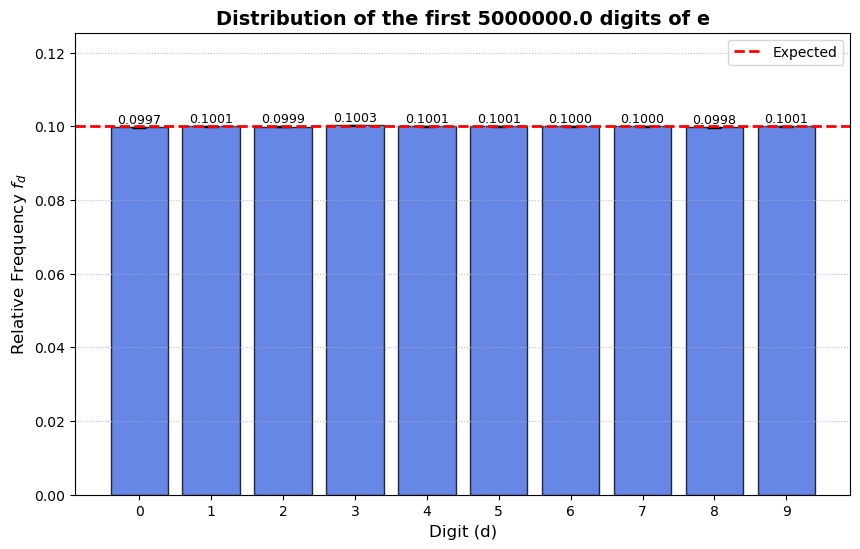

Reduced chi-squared = 1.9195
p-value = 0.0526


<IPython.core.display.Math object>

<IPython.core.display.Math object>

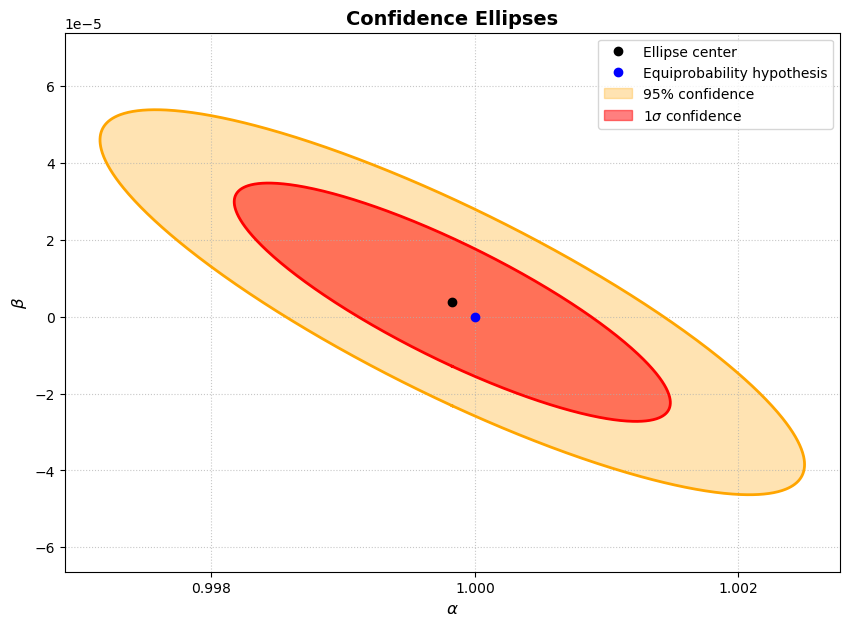

In [261]:
#analisis of the e number
N= 5e6
number_analysis('e', N, f'Distribution of the first {N} digits of e')

best estimation of a = (9.96 ± 0.074) × 10^-1
best estimation of b = (9.0 ± 14.0) × 10^-5
 covariance matrix
[[ 5.49007168e-05 -8.67585238e-07]
 [-8.67585238e-07  1.93065899e-08]]


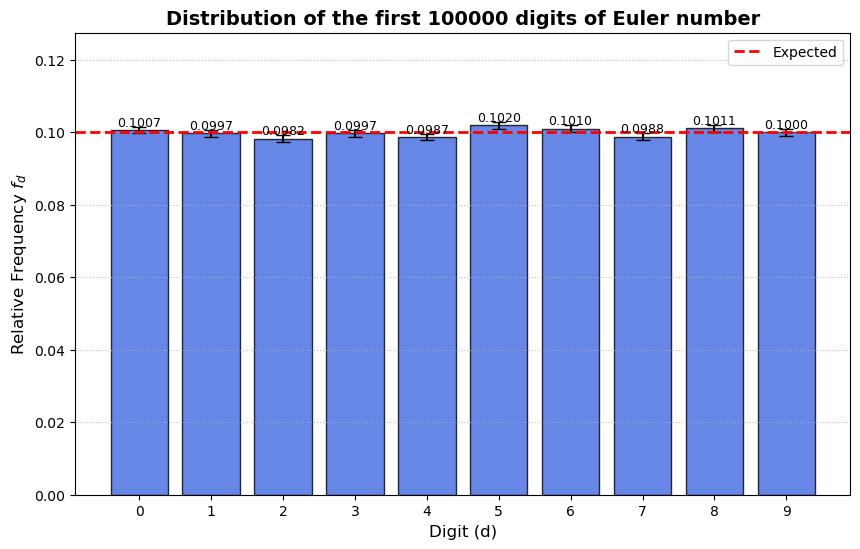

Reduced chi-squared = 1.7684
p-value = 0.0780


<IPython.core.display.Math object>

<IPython.core.display.Math object>

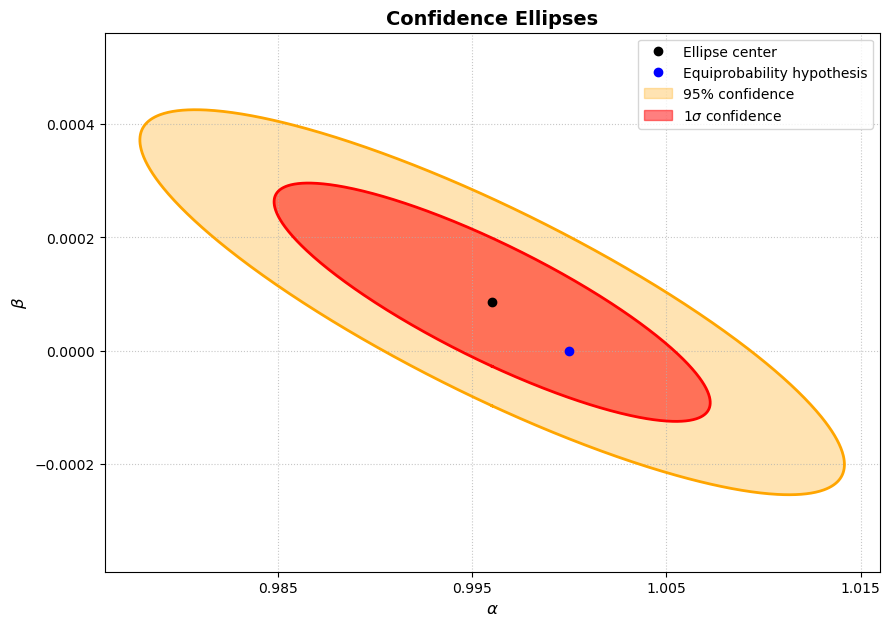

In [262]:
#analisis of the euler number
number_analysis('euler', 1e5, f'Distribution of the first {int(1e5)} digits of Euler number')

best estimation of a = (9.9938 ± 0.0079) × 10^-1
best estimation of b = (1.4 ± 1.5) × 10^-5
 covariance matrix
[[ 6.24676753e-07 -9.86360257e-09]
 [-9.86360257e-09  2.19240592e-10]]


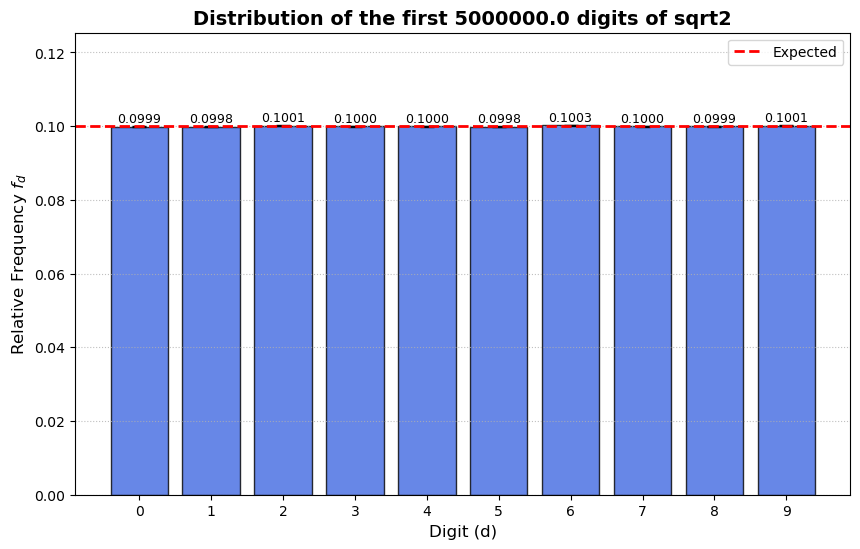

Reduced chi-squared = 1.0051
p-value = 0.4295


<IPython.core.display.Math object>

<IPython.core.display.Math object>

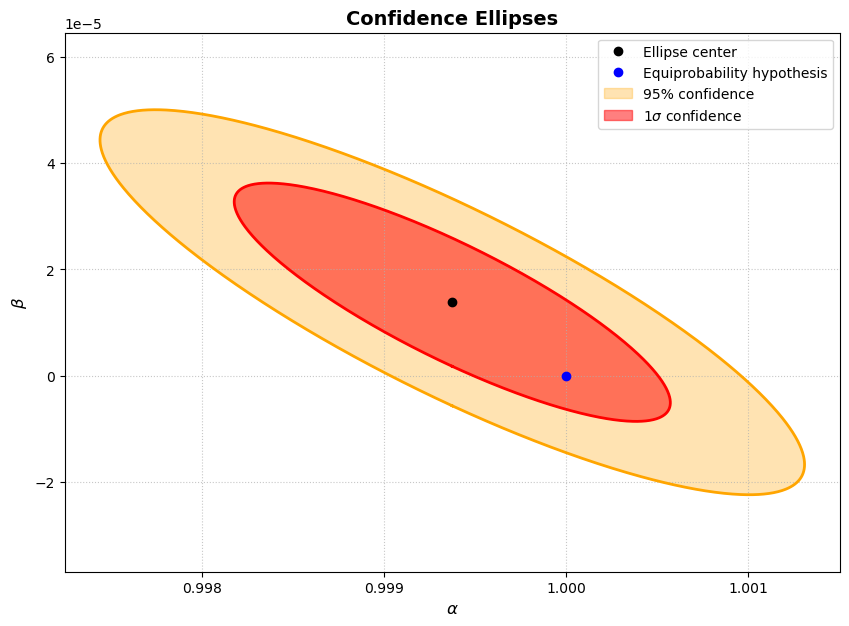

In [263]:
#analisis of sqrt2 number
number_analysis('sqrt2', N, f'Distribution of the first {N} digits of sqrt2')

best estimation of a = (1.00027 ± 0.00045) × 10^0
best estimation of b = (-6.1 ± 8.5) × 10^-6
 covariance matrix
[[ 2.03611740e-07 -3.21454462e-09]
 [-3.21454462e-09  7.14271287e-11]]


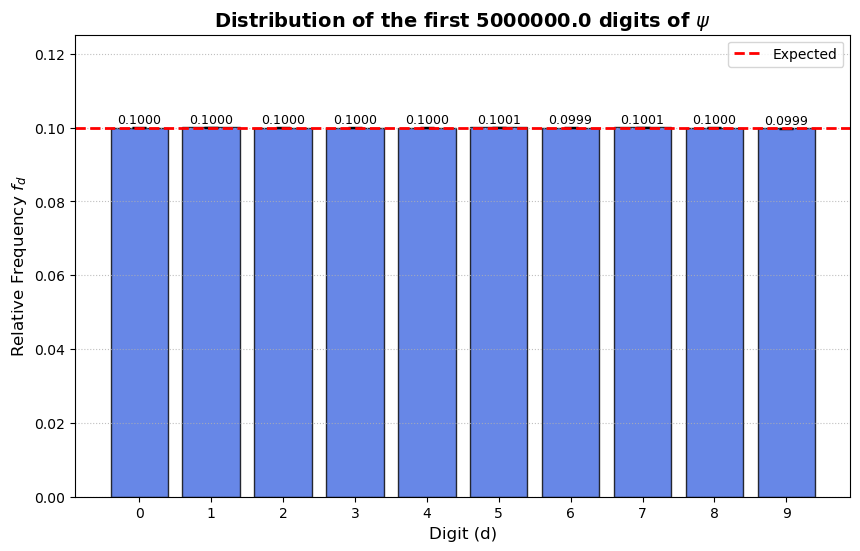

Reduced chi-squared = 0.3275
p-value = 0.9559


<IPython.core.display.Math object>

<IPython.core.display.Math object>

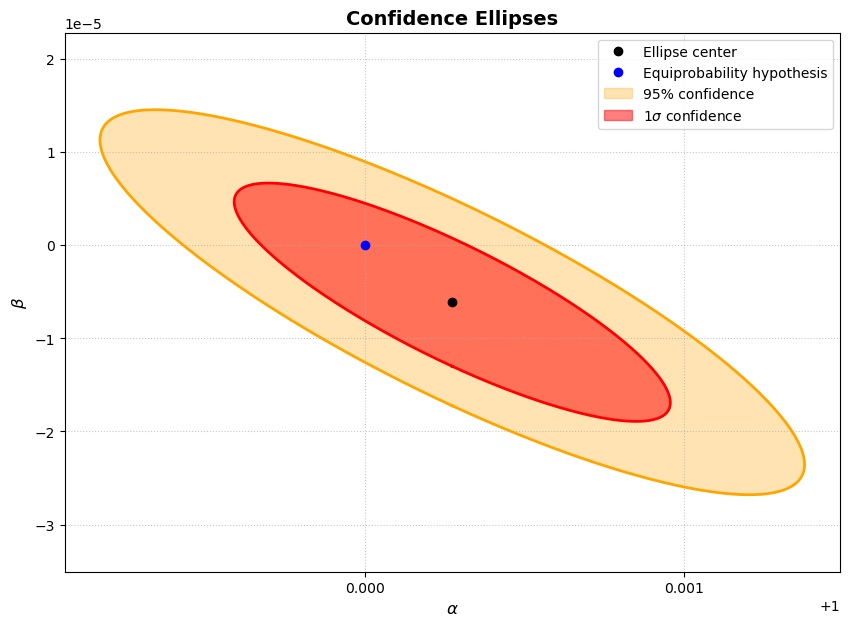

In [264]:
#analisis of golden ratio number
number_analysis('phi', N, f'Distribution of the first {N} digits of $\psi$')

best estimation of a = (1.008 ± 0.013) × 10^0
best estimation of b = (-1.9 ± 2.5) × 10^-4
 covariance matrix
[[ 1.77604483e-04 -2.80894161e-06]
 [-2.80894161e-06  6.22337348e-08]]


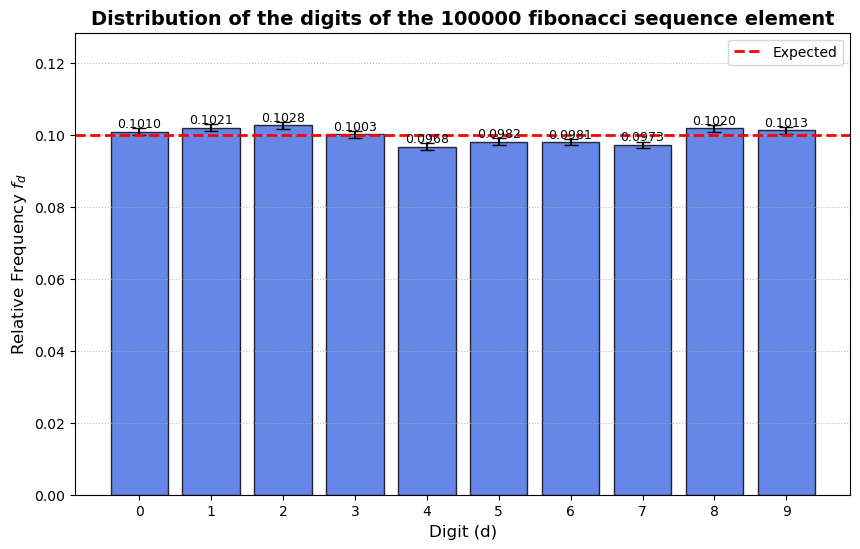

Reduced chi-squared = 5.6493
p-value = 0.0000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

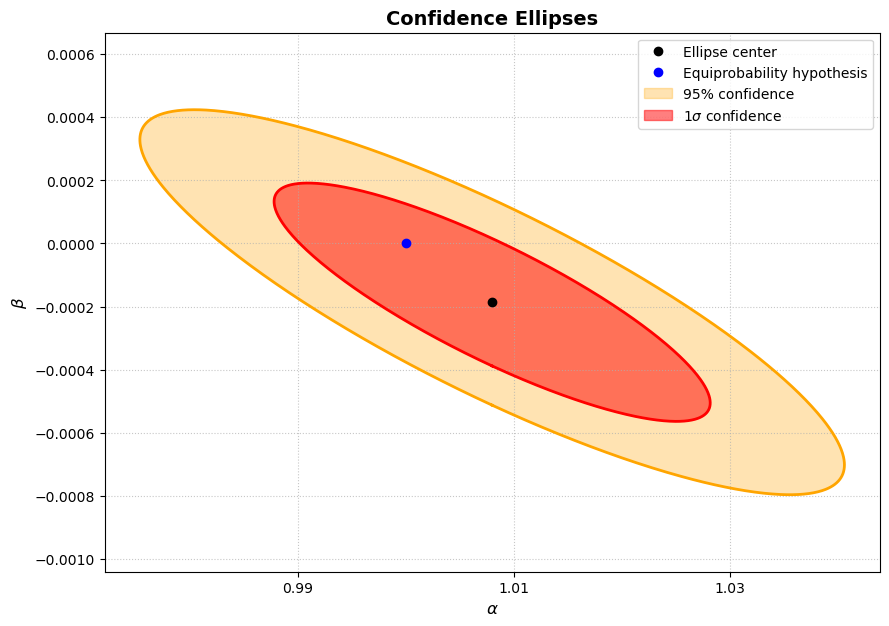

In [265]:
#analisis of the fibonacci sequence
N= int(1e5) #adapted N
number_analysis('fibonacci', N, f'Distribution of the digits of the {N} fibonacci sequence element')

best estimation of a = (1.008 ± 0.015) × 10^0
best estimation of b = (-1.8 ± 2.8) × 10^-4
 covariance matrix
[[ 2.30442552e-04 -3.64508961e-06]
 [-3.64508961e-06  8.07699414e-08]]


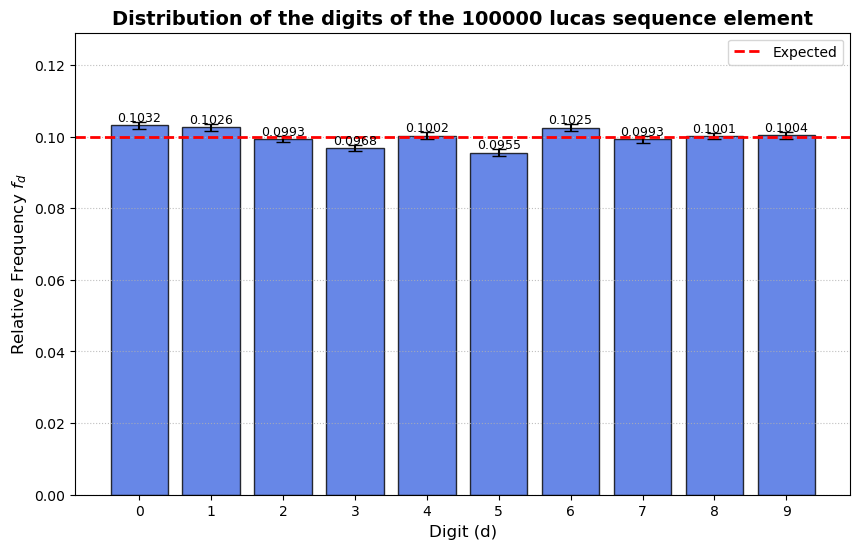

Reduced chi-squared = 7.3306
p-value = 0.0000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

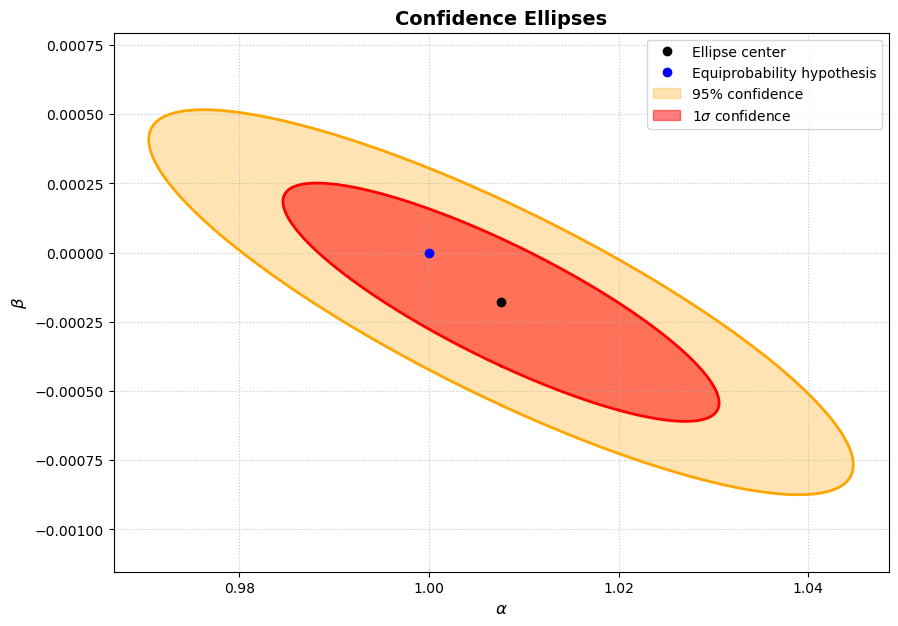

In [266]:
#analisis of the lucas sequence
number_analysis('lucas', N, f'Distribution of the digits of the {N} lucas sequence element')

best estimation of a = (9.97 ± 0.11) × 10^-1
best estimation of b = (7.0 ± 21.0) × 10^-5
 covariance matrix
[[ 1.30966085e-04 -2.06655848e-06]
 [-2.06655848e-06  4.59774780e-08]]


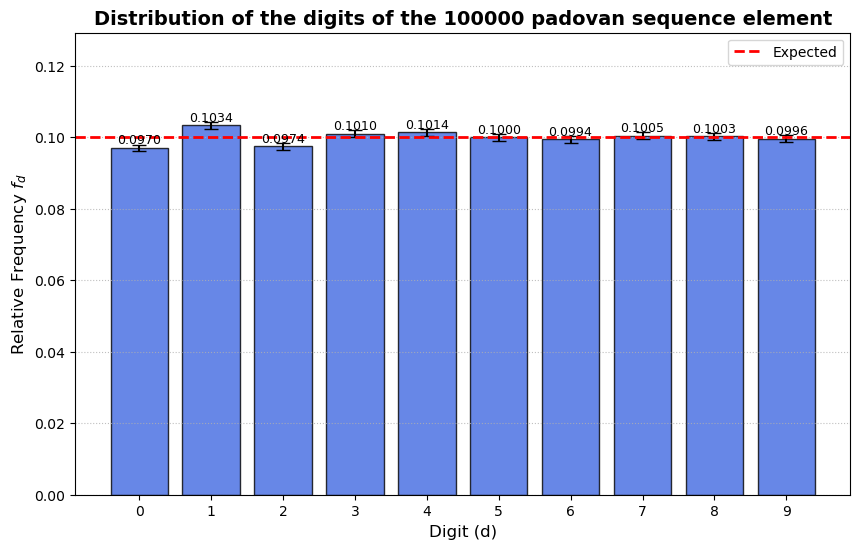

Reduced chi-squared = 4.2323
p-value = 0.0000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

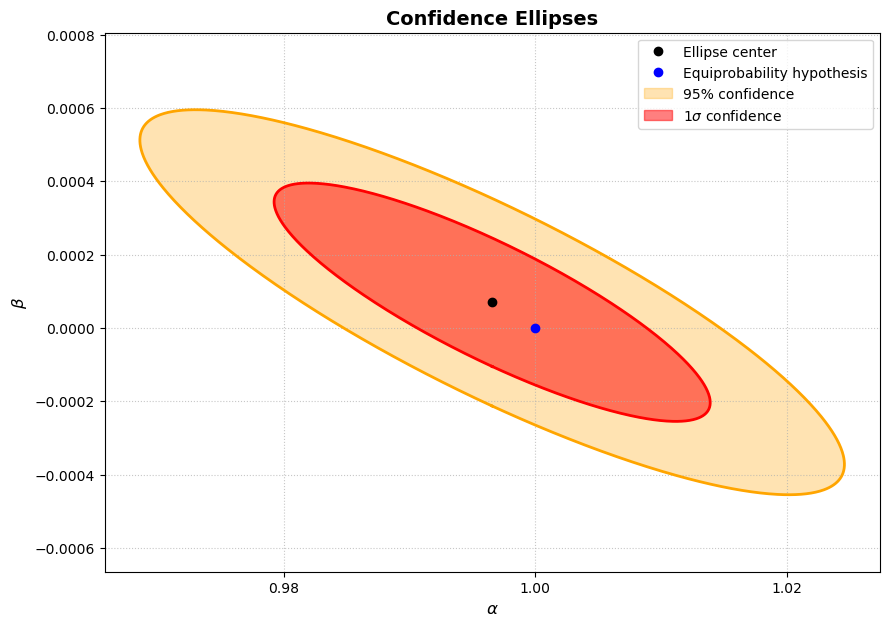

In [267]:
#analisis of the padovan sequence
number_analysis('padovan', N, f'Distribution of the digits of the {N} padovan sequence element')

The considerations discussed above for $\pi$ also apply to the other numbers analyzed in this study. In all cases, the frequency distributions of the digits show a high level of agreement with the expected uniform behavior. Moreover, it is clearly observed that the digit frequencies converge toward the expected value of 0.1 as the number of analyzed digits increases, exactly as predicted by statistical theory.

This progressive convergence highlights the law of large numbers, confirming that any small deviations observed for smaller samples are purely statistical fluctuations. The consistency of these results across all tested numbers reinforces the conclusion that their digits behave as independent and uniformly distributed random variables, within the limits of numerical precision.


## Second part

1. Following the steps of section I, extract the frequencies $f_d$ (d in [1, 9]) in the 1st-digit of the
Fibonacci numbers $F_n$ (n = 0, N ); draw the frequency histogram with error-bars and adjust the
ad-hoc mode

In [268]:
#model for testing the Benford-distribution hypothesis  
def Benford_dist(d, a, b):
   return np.log10(d + a) - np.log10(d + b)


best estimation of a = (9.91 ± 0.26) × 10^-1
best estimation of b = (-6.0 ± 17.0) × 10^-3
 covariance matrix
[[0.00069338 0.00044675]
 [0.00044675 0.00030332]]


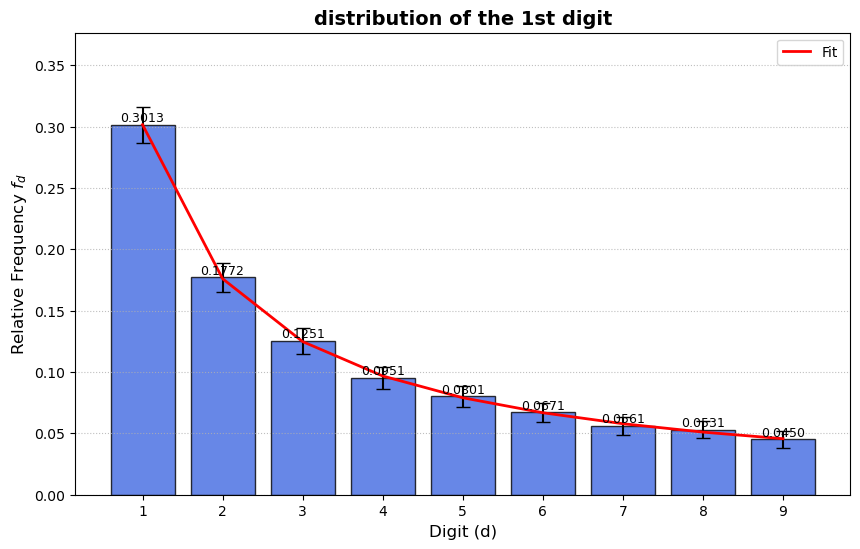

Reduced chi-squared = 0.0299
p-value = 1.0000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

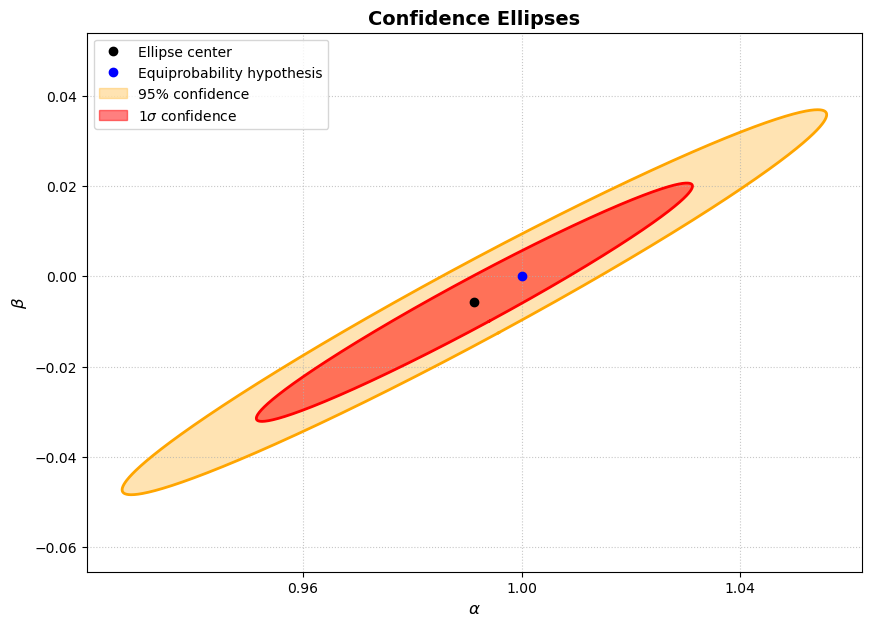

In [269]:
N = int(1e3) 
digits = np.arange(1,10) #The zero is excluded.
digit_count = {str(d): 0 for d in digits}
for step in range(1,N): #The zero is excluded since mp.fibonacci(0)=0.
    F = str(mp.fibonacci(step))
    digit_count[F[0]] += 1
    
# Convert the dictionary into an ordered NumPy array
freq_array = np.array([digit_count[str(d)] for d in digits])/(N-1)

# Compute the binomial standard deviation for each frequency
# sigma = sqrt(p*(1-p)/N).
error = np.sqrt(freq_array * (1 - freq_array) / (N-1))

par, cov = optimize.curve_fit(
    Benford_dist,
    digits,
    freq_array,
    sigma=error,
    p0=(1.0, 0.0),
    bounds = ([0, -0.5], [2,2])
)

aBest, bBest = par
aErr, bErr = np.sqrt(np.diag(cov))

# Print results in scientific notation  
print_scientific("best estimation of a", aBest, aErr)
print_scientific("best estimation of b", bBest, bErr)
    
print('='*80, '\n', 'covariance matrix')
print(cov)

plot_freq(freq_array,
          error,
          expected=None,
          overlay=Benford_dist(digits, aBest, bBest),
          title ='distribution of the 1st digit',
          digits= digits)

calculate_chi(freq_array, error, Benford_dist, np.arange(1,10), aBest, bBest)
draw_ellipse(cov, aBest, bBest)


with a covariance matrix indicating small correlations and reasonable uncertainties. Both parameters are very close to the expected values ($\alpha$ = 1, $\beta$ = 0), showing excellent agreement between the observed frequencies and the theoretical Benford distribution.

The reduced chi-squared value of $\sim$ 0.03 is extremely low, and the corresponding p-value of 1.0 confirms that the fit is statistically perfect within the uncertainties of the measurements. The Δχ² test for the hypothesis point (a₀, b₀) also gives a negligible value with p = 1, further reinforcing that the expected Benford parameters are fully compatible with the observed data.

The histogram of first-digit frequencies, overlaid with the fitted Benford curve, visually confirms the agreement. : This demonstrates that the leading digits of Fibonacci numbers conform very well to Benford’s law, even for a relatively small sample of N = 1000 terms.

2. It has been shown (Boyle, 1994) that any number that results from the multiplication of a large number of independent random variables asymptotically follow the Benford law. Following the above steps, check this behaviour for the variable $Z_n = \prod_{k=0}^n X_k$, where $X_k$ are uniformly-distributed random variables, for different increasing values of n.

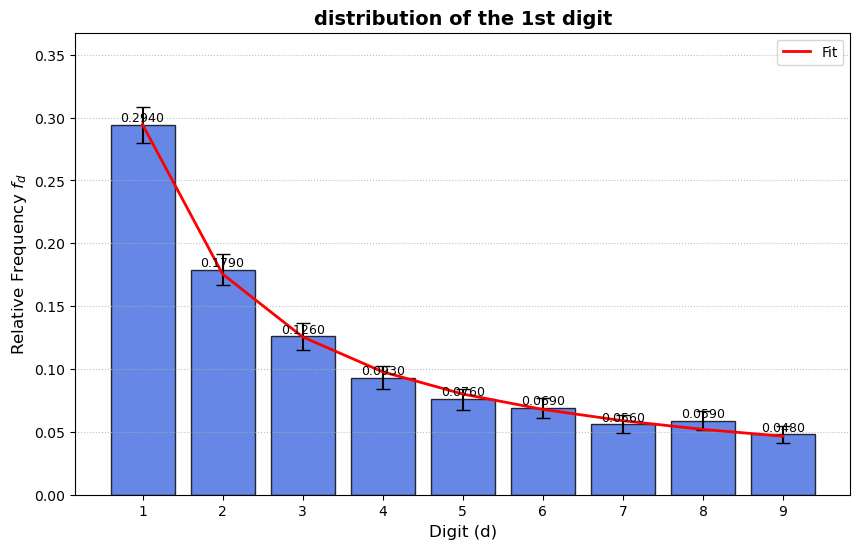

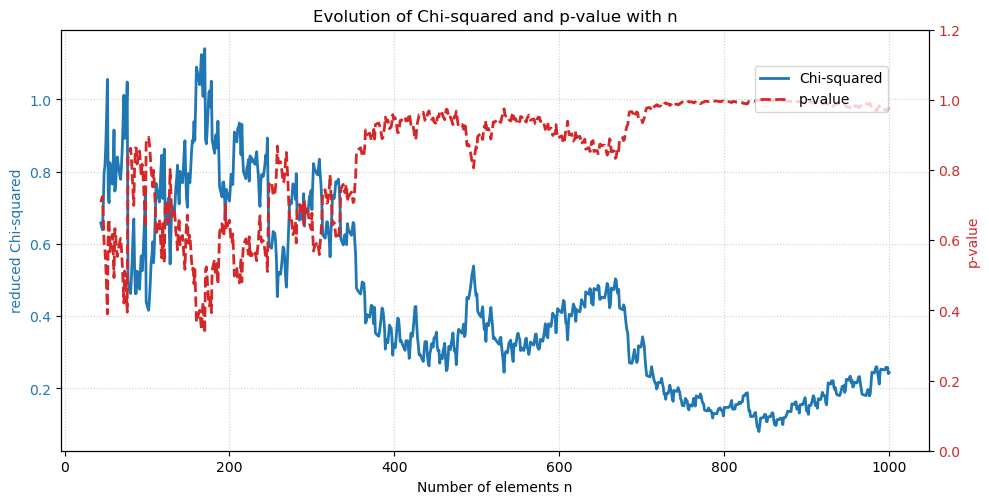

In [275]:
N = int(1e3)
chi_vals = []
p_vals = []
digits = np.arange(1, 10)
dof = len(digits) - 2                          # degrees of freedom
digit_count = {str(d): 0 for d in digits}
zk = np.cumprod(np.random.uniform(1, 1.5, size=N))  # generate cumulative product of random numbers
valid_indices = [] # store n for which fit is done
digit_count = {str(d): 0 for d in digits}  # initialize count dictionary

# Loop through each number in zk
for i, num in enumerate(zk, start=1):
    first_digit = str(int(num))               
    first_digit = first_digit[0]              
    digit_count[first_digit] += 1
    # Compute relative frequencies for this step
    freq_it = np.array([digit_count[str(d)] for d in digits])/i
    # Compute binomial standard deviation for each digit
    err = np.sqrt(freq_it * (1 - freq_it) / i)
    if 0 in freq_it:
            continue
        # Fit Benford distribution to the frequencies
    
    par, cov = optimize.curve_fit(
        Benford_dist,
        digits,
        freq_it,
        sigma=err,
        bounds=([0, -0.5], [2, 2]))
        
    
    # Calculate chi-squared and p-value for the fit
    expected = Benford_dist(digits, *par)         # expected frequencies from fit
    chi_sq = np.sum(((freq_it - expected)/err)**2)
    chi_vals.append(chi_sq/dof)
    p_vals.append(chi2.sf(chi_sq, dof)) # p-value
    valid_indices.append(i) 

#plot the last iteration results
plot_freq(freq_it,
          err,
          expected=None,
          overlay=Benford_dist(digits, *par),
          title ='distribution of the 1st digit',
          digits= digits)

# Plot Chi-squared and p-value on the same figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Number of elements n')
ax1.set_ylabel('reduced Chi-squared', color='tab:blue')
ax1.plot(valid_indices, chi_vals, color='tab:blue', lw=2, label='Chi-squared')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.set_ylabel('p-value', color='tab:red')
ax2.plot(valid_indices, p_vals, color='tab:red', lw=2, linestyle='--', label='p-value')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0,1.2)

fig.tight_layout()
plt.title('Evolution of Chi-squared and p-value with n')
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.9))
plt.show()


The results of this simulation show that the first-digit distribution of the cumulative product sequence converges toward the Benford distribution as the number of elements n increases. The plot of reduced chi-squared and p-value as functions of n clearly illustrates this behavior. But the results is also effected by the seed used in the generation.

The reduced chi-squared values decrease , approaching values close to zero, indicating that the fit between the observed frequencies and the Benford model improves with larger samples.

Correspondingly, the p-values increase, approaching 1, which confirms that the observed distributions become statistically fully compatible with the Benford law.

This demonstrates the law of large numbers in action: small statistical fluctuations at low n gradually average out, and the cumulative product sequence rapidly exhibits the expected logarithmic distribution of first digits. Overall, the agreement is good, and the trends confirm that even random multiplicative sequences obey Benford’s law very accurately as the sample size grows.

Similarly, check that the 1st-digit of the variable $Z_n = (\frac{X}{Y})^n$, where both X and Y are uniformly distributed, rapidly tends to the Bendford law for n $\geq$ 5


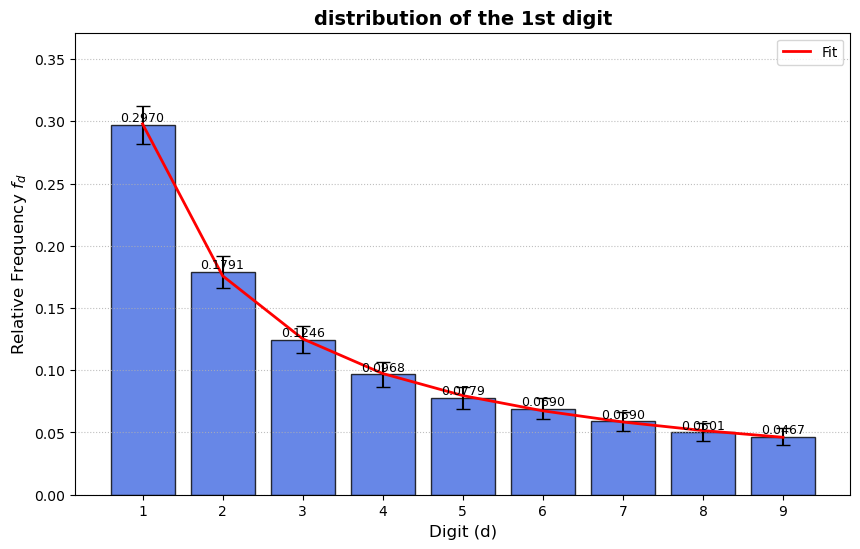

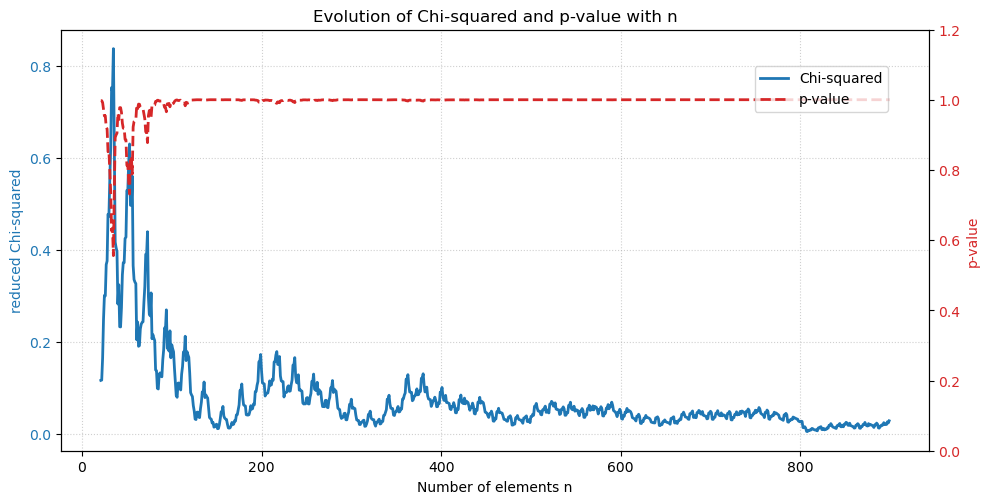

In [271]:
N = int(900)
chi_vals = []
p_vals = []
digits = np.arange(1, 10)
dof = len(digits) - 2                          # degrees of freedom
digit_count = {str(d): 0 for d in digits}
x,y = np.random.uniform(1, 2), np.random.uniform(1, 2)
#TO MAKE THE CODE MORE STABLE
if x>y:
    frac=x/y
else:
    frac = y/x
zk = np.array([frac**n for n in range(1,N)])  # generate cumulative product of random numbers
valid_indices = [] # store n for which fit is done
digit_count = {str(d): 0 for d in digits}  # initialize count dictionary

# Loop through each number in zk
for i, num in enumerate(zk, start=1):
    first_digit = str(int(num))               
    first_digit = first_digit[0]              
    digit_count[first_digit] += 1
    # Compute relative frequencies for this step
    freq_it = np.array([digit_count[str(d)] for d in digits])/i
    # Compute binomial standard deviation for each digit
    err = np.sqrt(freq_it * (1 - freq_it) / i)
    if 0 in freq_it:
        continue
        # Fit Benford distribution to the frequencies
    
    par, cov = optimize.curve_fit(
        Benford_dist,
        digits,
        freq_it,
        sigma=err,
        bounds=([0, -0.5], [2, 2]))
        
    # Calculate chi-squared and p-value for the fit
    expected = Benford_dist(digits, *par)         # expected frequencies from fit
    chi_sq = np.sum(((freq_it - expected)/err)**2)
    chi_vals.append(chi_sq/dof)
    p_vals.append(chi2.sf(chi_sq, dof)) # p-value
    valid_indices.append(i) 

#plot the last iteration results
plot_freq(freq_it,
          err,
          expected=None,
          overlay=Benford_dist(digits, *par),
          title ='distribution of the 1st digit',
          digits= digits)

# Plot Chi-squared and p-value on the same figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Number of elements n')
ax1.set_ylabel('reduced Chi-squared', color='tab:blue')
ax1.plot(valid_indices, chi_vals, color='tab:blue', lw=2, label='Chi-squared')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.set_ylabel('p-value', color='tab:red')
ax2.plot(valid_indices, p_vals, color='tab:red', lw=2, linestyle='--', label='p-value')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0,1.2)

fig.tight_layout()
plt.title('Evolution of Chi-squared and p-value with n')
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.9))
plt.show()


The previous observations regarding the convergence to the Benford distribution are even more evident in this case, the trend is much more clearly delineated. For greater numerical stability in the computations, the code was modified to divide the larger number by the smaller one at each step, which reduces the risk of overflow or precision errors.

This approach allows the evolution of the first-digit frequencies, chi-squared values, and p-values to be tracked reliably, and it further highlights how the distribution quickly aligns with the Benford law as n increases.